# Dinemtionality reduction

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_circles, make_moons, load_breast_cancer, make_swiss_roll
from sklearn.svm import SVC, LinearSVC, NuSVC
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA, KernelPCA
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import MDS, TSNE
import time

# PCA

## MNIST Dataset

- 7000 изображений
- 28x28 пикселей = 784 признака

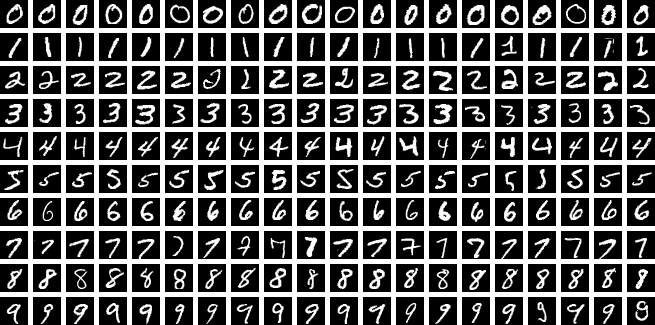

In [2]:
# load data
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target.astype(int)

In [3]:
# inpect data
print(X.shape)
print(X.min(), X.max())

(70000, 784)
0 255


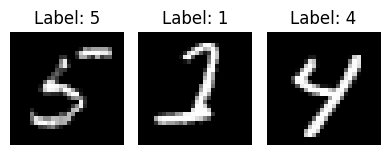

In [4]:
# visualize images
fig, axes = plt.subplots(1, 3, figsize=(4, 8))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(X))
    img = X[idx].reshape(28, 28)
    
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {y[idx]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [5]:
pca = PCA(n_components=2)
X_transformed = pca.fit_transform(X)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Cumulative explained variance ratio: {np.sum(pca.explained_variance_ratio_):.2f}")

Explained variance ratio: [0.09746116 0.07155445]
Cumulative explained variance ratio: 0.17


In [6]:
# task
# plot EVR and CVR for different number of components up to 100

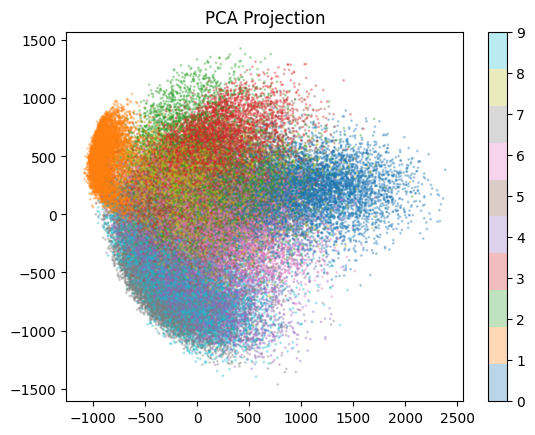

In [8]:
# visualizing the first 2 components
plt.scatter(X_transformed[:, 0], X_transformed[:, 1], c=y, cmap='tab10', alpha=0.3, s=1)
plt.title("PCA Projection")
plt.colorbar()
plt.show()

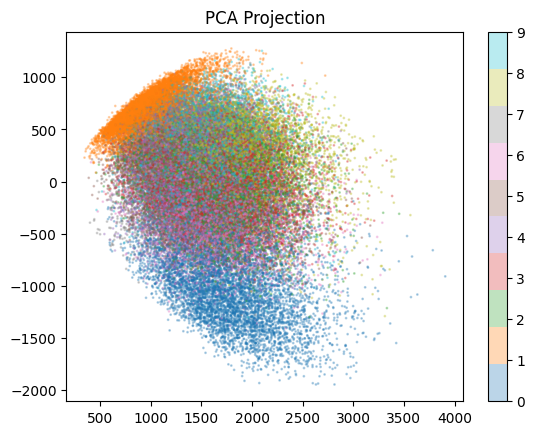

In [9]:
# compare with TruncatedSVD
svd = TruncatedSVD(n_components=2)
X_svd = svd.fit_transform(X)

plt.scatter(X_svd[:, 0], X_svd[:, 1], c=y, cmap='tab10', alpha=0.3, s=1)
plt.title("PCA Projection")
plt.colorbar()
plt.show()

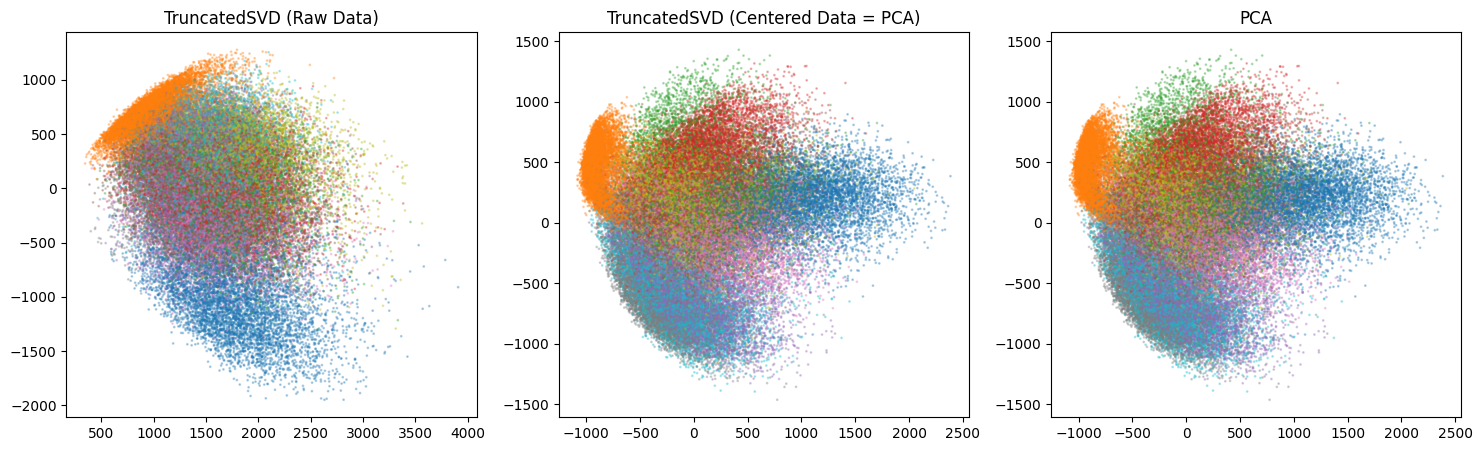

In [10]:
# TruncatedSVD on raw data
svd_raw = TruncatedSVD(n_components=2)
X_svd_raw = svd_raw.fit_transform(X)

# TruncatedSVD on centered data
X_centered = X - X.mean(axis=0)
svd_centered = TruncatedSVD(n_components=2)
X_svd_centered = svd_centered.fit_transform(X_centered)

# visualization with PCA
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.scatter(X_svd_raw[:, 0], X_svd_raw[:, 1], c=y, cmap='tab10', s=1, alpha=0.3)
ax1.set_title("TruncatedSVD (Raw Data)")

ax2.scatter(X_svd_centered[:, 0], X_svd_centered[:, 1], c=y, cmap='tab10', s=1, alpha=0.3)
ax2.set_title("TruncatedSVD (Centered Data = PCA)")

ax3.scatter(X_transformed[:, 0], X_transformed[:, 1], c=y, cmap='tab10', s=1, alpha=0.3)
ax3.set_title("PCA")

plt.show()

In [11]:
# compare SVD solvers speed
solvers = ['full', 'randomized']
n_comp = 100

for s in solvers:
    start = time.time()
    pca_bench = PCA(n_components=n_comp, svd_solver=s)
    pca_bench.fit(X)
    print(f"Solver: {s} | Time: {time.time() - start:.2f}s")

Solver: full | Time: 6.26s
Solver: randomized | Time: 2.16s


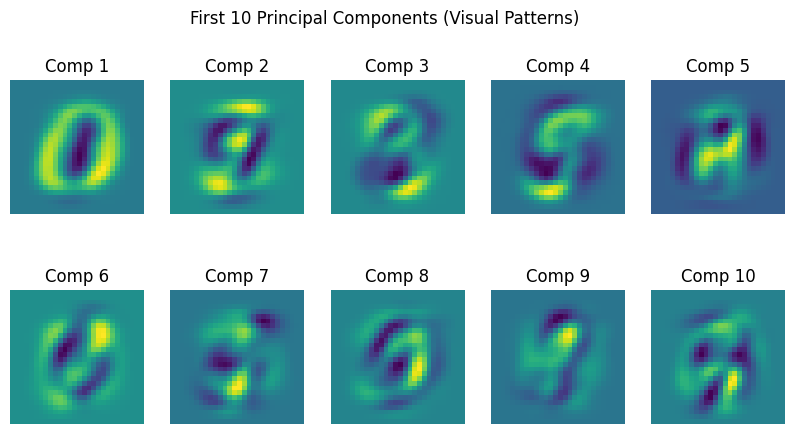

In [12]:
# visualizing first 10 components

pca_85 = PCA(n_components=80)
X_pca_85 = pca_85.fit_transform(X)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    eigen_digit = pca_85.components_[i].reshape(28, 28)
    ax.imshow(eigen_digit, cmap='viridis')
    ax.set_title(f"Comp {i+1}")
    ax.axis('off')
plt.suptitle("First 10 Principal Components (Visual Patterns)")
plt.show()

Text(0.5, 1.0, '85 Components Reconstructed')

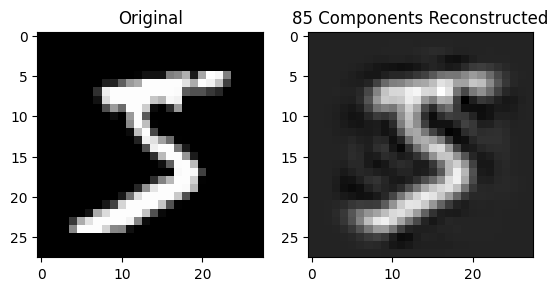

In [13]:
# reconstructing a digit
X_reconstructed = pca_85.inverse_transform(X_pca_85)

idx = 0
plt.subplot(1, 2, 1)
plt.imshow(X[idx].reshape(28, 28), cmap='gray')
plt.title("Original")
plt.subplot(1, 2, 2)
plt.imshow(X_reconstructed[idx].reshape(28, 28), cmap='gray')
plt.title("85 Components Reconstructed")

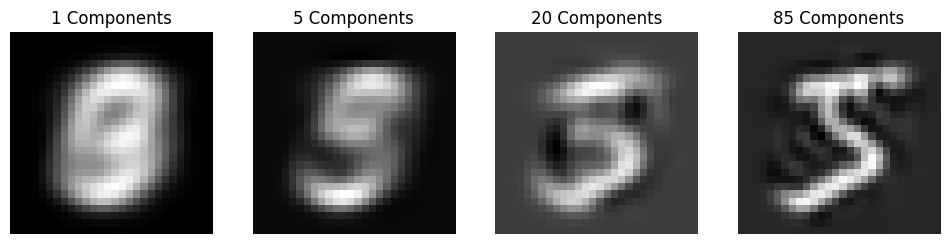

In [14]:
# visualizing reconstruction for different number of components
sample_idx = 0
sample_digit = X[sample_idx]

n_comps = [1, 5, 20, 85]
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for i, n in enumerate(n_comps):
    pca_temp = PCA(n_components=n)
    X_proj = pca_temp.fit_transform(X)
    X_rec = pca_temp.inverse_transform(X_proj)

    axes[i].imshow(X_rec[sample_idx].reshape(28,28), cmap='gray')
    axes[i].set_title(f"{n} Components")
    axes[i].axis('off')

plt.show()


In [15]:
# task
# code a function that chooses the best number of components based on CVR
# func choose_n_components(X, y, n_components, cvr_threshold) -> int:

In [17]:
get_best_n_components(X, y, 100, 0.9)

87

In [18]:
# another way of doing the same thing
pca_with_threshold = PCA(n_components=0.9)
pca_with_threshold.fit(X)

print(pca_with_threshold.n_components_)

87


## Kernel-PCA

In [19]:
# let's take smaller sample
n_samples = 2000
indices = np.random.choice(len(X), n_samples, replace=False)

X_small = X[indices]
y_small = y[indices]

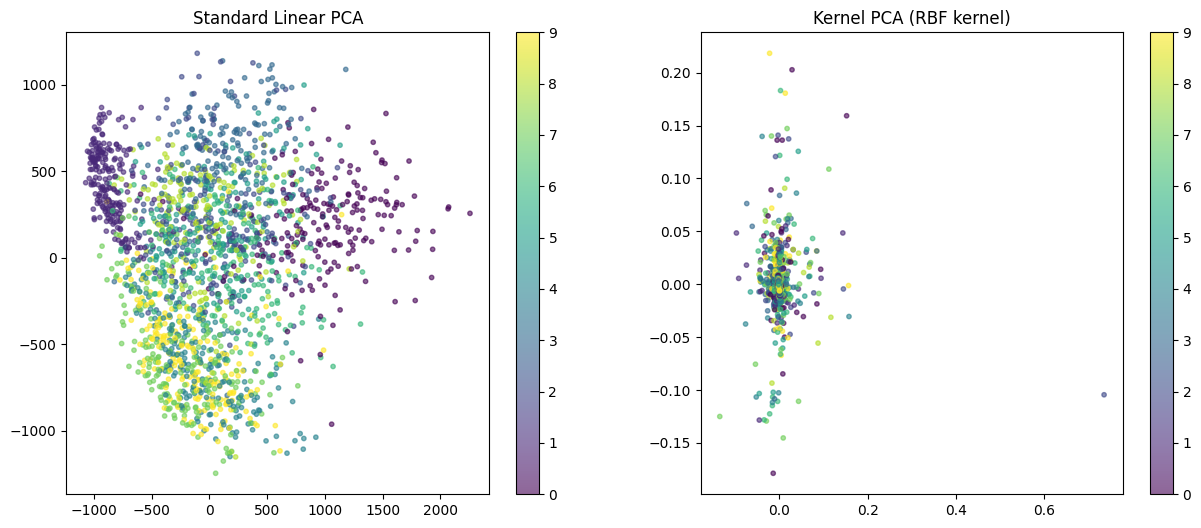

In [20]:
# linear PCA
pca_lin = PCA(n_components=2)
X_pca = pca_lin.fit_transform(X_small)

# Kernel PCA with RBF kernel
# assume gamma and alpha are fixed for simplicity
kpca_rbf = KernelPCA(n_components=2, kernel='rbf', gamma=1e-2, alpha=0.1)
X_kpca = kpca_rbf.fit_transform(X_small)

# visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sc1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y_small, s=10, alpha=0.6)
ax1.set_title("Standard Linear PCA")
plt.colorbar(sc1, ax=ax1)

sc2 = ax2.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y_small, s=10, alpha=0.6)
ax2.set_title("Kernel PCA (RBF kernel)")
plt.colorbar(sc2, ax=ax2)

plt.show()


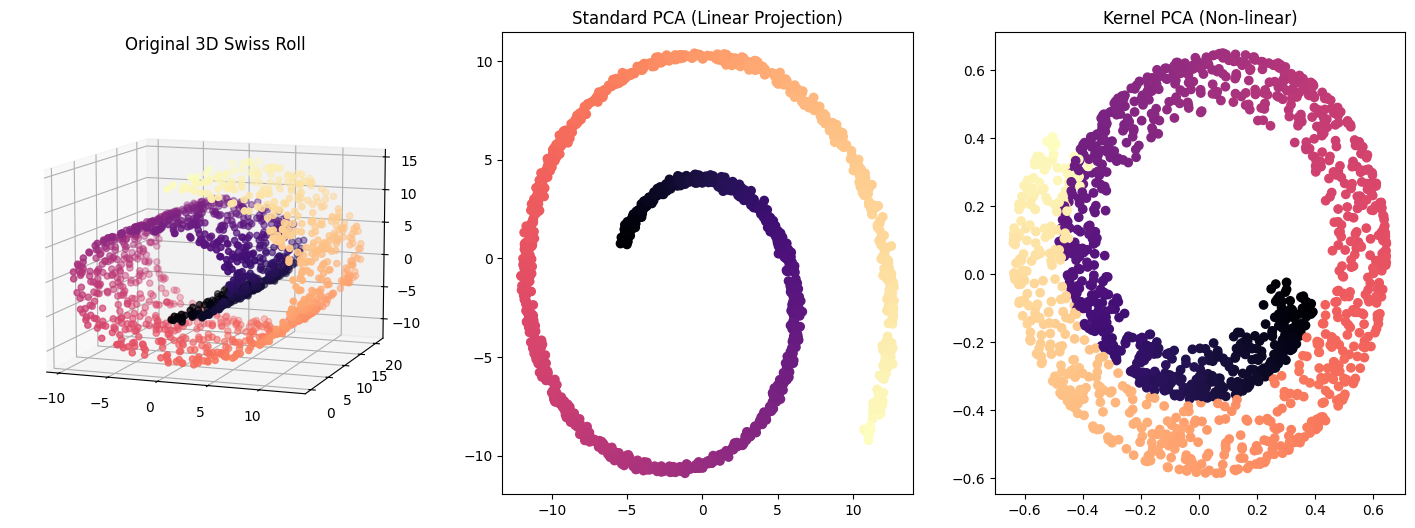

In [21]:
# generate data
X_sr, y_sr = make_swiss_roll(n_samples=1500, noise=0.1, random_state=42)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sr)

kpca = KernelPCA(n_components=2, kernel="rbf", gamma=0.004)
X_kpca = kpca.fit_transform(X_sr)

# visualize
fig = plt.figure(figsize=(18, 6))

# original data
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X_sr[:, 0], X_sr[:, 1], X_sr[:, 2], c=y_sr, cmap='magma')
ax1.set_title("Original 3D Swiss Roll")
ax1.view_init(10, -70)

# PCA
ax2 = fig.add_subplot(132)
ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=y_sr, cmap='magma')
ax2.set_title("Standard PCA (Linear Projection)")

# Kernel PCA
ax3 = fig.add_subplot(133)
ax3.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y_sr, cmap='magma')
ax3.set_title("Kernel PCA (Non-linear)")

plt.show()

## MDS

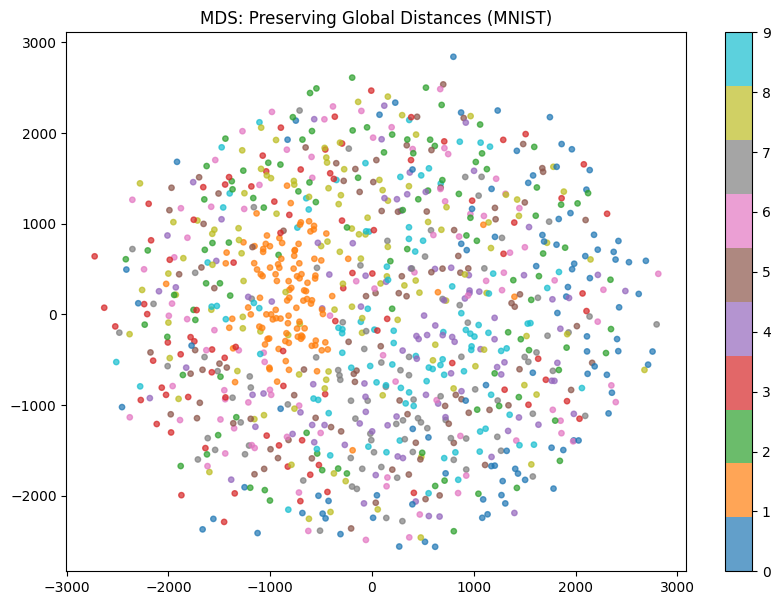

MDS Stress: 514010836353.49


In [22]:
# take smaller sample
n_mds_samples = 1000 
indices = np.random.choice(len(X), n_mds_samples, replace=False)
X_mds_sub = X[indices]
y_mds_sub = y[indices]

# metric=True means classic metric MDS with Euclidean distances
mds = MDS(n_components=2, metric=True, random_state=42, n_init=1, max_iter=100)
X_mds = mds.fit_transform(X_mds_sub)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_mds[:, 0], X_mds[:, 1], c=y_mds_sub, cmap='tab10', s=15, alpha=0.7)
plt.colorbar(scatter)
plt.title("MDS: Preserving Global Distances (MNIST)")
plt.show()

# calculate stress: lower is better
print(f"MDS Stress: {mds.stress_:.2f}")

## t-SNE

t-SNE compute time 4.74s


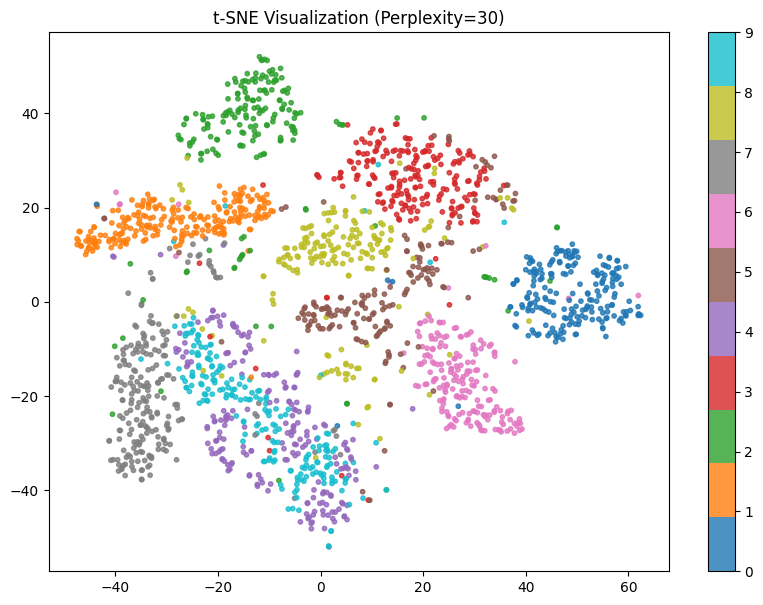

In [23]:
# capture calculation time
start_time = time.time()
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X_small)

print(f"t-SNE compute time {time.time() - start_time:.2f}s")

# visualize
plt.figure(figsize=(10, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_small, cmap='tab10', s=10, alpha=0.8)
plt.colorbar()
plt.title(f"t-SNE Visualization (Perplexity=30)")
plt.show()

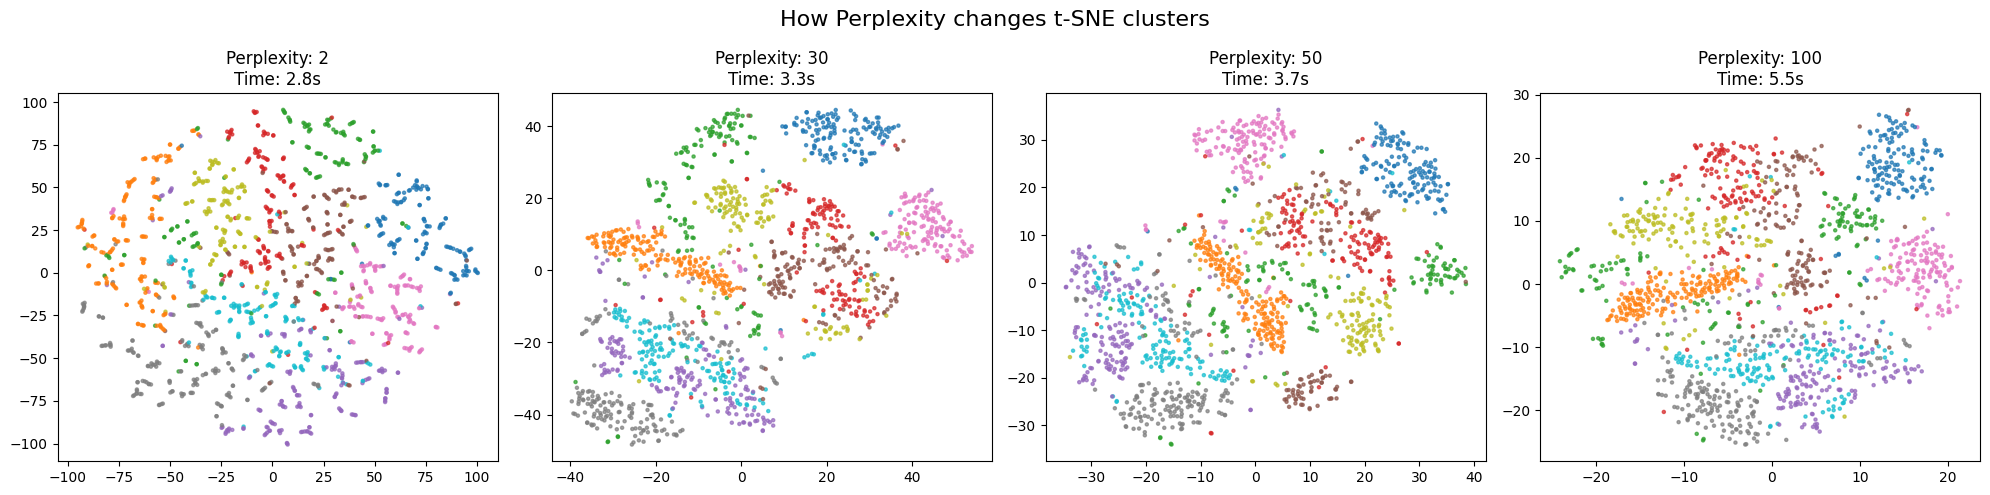

In [24]:
# even smaller sample for speed
n_samples = 1500
X_mini = X[:n_samples]
y_mini = y[:n_samples]

perplexities = [2, 30, 50, 100]

fig, axes = plt.subplots(1, len(perplexities), figsize=(20, 5))

for i, p in enumerate(perplexities):
    start = time.time()

    tsne = TSNE(n_components=2, perplexity=p, init='pca', max_iter=1000, random_state=42)
    X_embedded = tsne.fit_transform(X_mini)

    duration = time.time() - start

    ax = axes[i]
    scatter = ax.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y_mini, cmap='tab10', s=5, alpha=0.7)
    ax.set_title(f"Perplexity: {p}\nTime: {duration:.1f}s")

plt.suptitle("How Perplexity changes t-SNE clusters", fontsize=16)
plt.tight_layout()
plt.show()


further reading: https://distill.pub/2016/misread-tsne/

In [ ]:
# Task
# given a data sample X:
#  - [x] take a small sample of 1000 observations
#  - [ ] split into train/test by factor 0.2
#  - [ ] train SVC classifier with linear kernel
#  - [ ] print training speed and accuracy
#  - [ ] train X_train with PCA and transform data with 50 components
#  - [ ] train SVC with transformed X sample
#  - [ ] print training speed and accuracy, compare

In [ ]:
sample_size = 1000
X_sample, y_sample = X[:sample_size], y[:sample_size]